# Network Anomaly Detection với CSE-CIC-IDS2018

**Notebook Google Colab phục vụ bài thi cuối kỳ Deep Learning**

Notebook xây dựng một pipeline phát hiện bất thường mạng hoàn chỉnh và so sánh bốn kiến trúc:

1. **MLP** - baseline cho dữ liệu dạng bảng.
2. **1D-CNN** - học các mẫu cục bộ giữa các đặc trưng lân cận.
3. **BiLSTM** - xem vector đặc trưng như một chuỗi đặc trưng.
4. **Transformer Encoder** - dùng self-attention để học quan hệ toàn cục giữa các đặc trưng.

Sản phẩm đáp ứng các đầu mục chính trong tài liệu môn học: Train/Validation/Test, loss train/validation, confusion matrix, prediction visualization, Attention, bảng so sánh, failure analysis, lưu mô hình và live demo.

## 0. Thiết kế thực nghiệm

- **Mặc định:** phân loại nhị phân `BENIGN` và `ATTACK`. Đây là cấu hình ổn định nhất cho live demo trên Colab.
- Có thể đổi `TASK = "multiclass"` để phân loại từng loại tấn công.
- Dữ liệu được chia **70% train, 15% validation, 15% test** bằng stratified split.
- Median imputation và RobustScaler **chỉ fit trên train** để tránh data leakage.
- Macro-F1 là chỉ số chính vì CIC-IDS2018 mất cân bằng mạnh; Accuracy chỉ là chỉ số bổ sung.
- Mỗi flow có hơn 80 thống kê do CICFlowMeter-V3 trích xuất. Tài liệu chính thức mô tả bảy kịch bản tấn công và cho phép tải CSV để phân tích AI.

In [ ]:
%pip install -q "pandas>=2.0" "scikit-learn>=1.3" seaborn joblib


In [ ]:
import os
import gc
import re
import json
import time
import random
import shutil
import warnings
import zipfile
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    roc_curve,
)
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Cấu hình


In [ ]:
# ======================== CẤU HÌNH CHÍNH ========================
TASK = "binary"                 # "binary" hoặc "multiclass"
USE_GOOGLE_DRIVE = True

DRIVE_ZIP_PATH = "/content/drive/MyDrive/CICIDS2018.zip"

WORK_DIR = Path("/content/cicids2018_work")
ARTIFACT_DIR = Path("/content/cicids2018_artifacts")

READ_CHUNK_SIZE = 100_000
MAX_ROWS_PER_FILE = 40_000       # Colab RAM-friendly
MAX_ROWS_PER_CLASS = 50_000      # Áp dụng sau khi gộp dữ liệu
MIN_SAMPLES_PER_CLASS = 100      # Chỉ dùng cho multiclass

TEST_SIZE = 0.15
VAL_SIZE = 0.15
EPOCHS = 15
BATCH_SIZE = 512
LEARNING_RATE = 1e-3
PATIENCE = 4

WORK_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

assert TASK in {"binary", "multiclass"}
assert TEST_SIZE + VAL_SIZE < 1


In [ ]:
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

if DRIVE_ZIP_PATH:
    zip_path = Path(DRIVE_ZIP_PATH)
    if not zip_path.exists():
        raise FileNotFoundError(f"Không tìm thấy ZIP: {zip_path}")
    extract_dir = WORK_DIR / "dataset"
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as archive:
        archive.extractall(extract_dir)
    DATA_DIR = extract_dir
else:
    DATA_DIR = Path(DRIVE_DATA_DIR)

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Không tìm thấy DATA_DIR={DATA_DIR}. Hãy sửa DRIVE_DATA_DIR/DRIVE_ZIP_PATH."
    )

csv_files = sorted(DATA_DIR.rglob("*.csv"))
print(f"Tìm thấy {len(csv_files)} file CSV trong {DATA_DIR}")
for path in csv_files[:10]:
    print(" -", path.name)
if not csv_files:
    raise FileNotFoundError("Không có file CSV nào trong thư mục dữ liệu.")


Mounted at /content/drive
Tìm thấy 10 file CSV trong /content/cicids2018_work/dataset
 - 02-14-2018.csv
 - 02-15-2018.csv
 - 02-16-2018.csv
 - 02-20-2018.csv
 - 02-21-2018.csv
 - 02-22-2018.csv
 - 02-23-2018.csv
 - 02-28-2018.csv
 - 03-01-2018.csv
 - 03-02-2018.csv


## 2. Đọc CIC-IDS2018 an toàn theo chunk

Các phiên bản CSV trên Internet có thể khác nhau về khoảng trắng trong tên cột. Hàm bên dưới:

- Chuẩn hóa tên cột bằng `strip()`.
- Tự tìm cột `Label`, không giả định có `Timestamp`.
- Không thực hiện xử lý timestamp, vì timestamp không bắt buộc cho mô hình này.
- Lấy mẫu mỗi file để giới hạn bộ nhớ.


In [ ]:
def find_label_column(columns):
    normalized = {str(c).strip().lower(): c for c in columns}
    for candidate in ("label", "class", "target", "attack"):
        if candidate in normalized:
            return normalized[candidate]
    return None


def normalize_label(value):
    value = re.sub(r"\s+", " ", str(value).strip())
    if TASK == "binary":
        return "BENIGN" if value.upper() == "BENIGN" else "ATTACK"
    return value


def read_sampled_csv(path, chunk_size=READ_CHUNK_SIZE, max_rows=MAX_ROWS_PER_FILE):
    selected = []
    rows_kept = 0
    try:
        reader = pd.read_csv(path, chunksize=chunk_size, low_memory=False)
        for chunk_id, chunk in enumerate(reader):
            chunk.columns = [str(c).strip() for c in chunk.columns]
            label_col = find_label_column(chunk.columns)
            if label_col is None:
                print(f"[SKIP] {path.name}: không tìm thấy cột Label")
                return None

            chunk = chunk.dropna(subset=[label_col]).copy()
            # Loại dòng header bị lặp bên trong CSV nếu có.
            chunk = chunk[chunk[label_col].astype(str).str.strip().str.lower() != "label"]
            if chunk.empty:
                continue

            remaining = max_rows - rows_kept
            if remaining <= 0:
                break

            # Lấy mẫu ngẫu nhiên trong từng chunk để tránh chỉ lấy phần đầu file.
            chunks_left_guess = 4
            target = min(len(chunk), remaining, max(1, max_rows // chunks_left_guess))
            sampled = chunk.sample(n=target, random_state=SEED + chunk_id)
            sampled["Label"] = sampled[label_col].map(normalize_label)
            if label_col != "Label":
                sampled = sampled.drop(columns=[label_col])
            sampled["__source_file"] = path.name
            selected.append(sampled)
            rows_kept += len(sampled)

            if rows_kept >= max_rows:
                break
    except Exception as exc:
        print(f"[ERROR] {path.name}: {exc}")
        return None

    if not selected:
        return None
    result = pd.concat(selected, ignore_index=True)
    print(f"[OK] {path.name}: {len(result):,} rows")
    return result


frames = []
for csv_path in csv_files:
    frame = read_sampled_csv(csv_path)
    if frame is not None:
        frames.append(frame)

if not frames:
    raise RuntimeError("Không đọc được file CSV hợp lệ nào.")

raw_df = pd.concat(frames, ignore_index=True, sort=False)
del frames
gc.collect()

print("Kích thước sau khi đọc mẫu:", raw_df.shape)
display(raw_df["Label"].value_counts(dropna=False).rename("count").to_frame())


[OK] 02-14-2018.csv: 40,000 rows
[OK] 02-15-2018.csv: 40,000 rows
[OK] 02-16-2018.csv: 40,000 rows
[OK] 02-20-2018.csv: 40,000 rows
[OK] 02-21-2018.csv: 40,000 rows
[OK] 02-22-2018.csv: 40,000 rows
[OK] 02-23-2018.csv: 40,000 rows
[OK] 02-28-2018.csv: 40,000 rows
[OK] 03-01-2018.csv: 40,000 rows
[OK] 03-02-2018.csv: 40,000 rows
Kích thước sau khi đọc mẫu: (400000, 85)


,count
Label,
BENIGN,215946
ATTACK,184054


## 3. Khám phá và cân bằng dữ liệu

Để thí nghiệm chạy được trong thời gian bảo vệ, mỗi lớp được giới hạn số dòng. Đây là **undersampling phục vụ tài nguyên**, không phải tạo dữ liệu giả. Tập test vẫn được giữ riêng sau khi chia.


,count
Label,
BENIGN,50000
ATTACK,50000


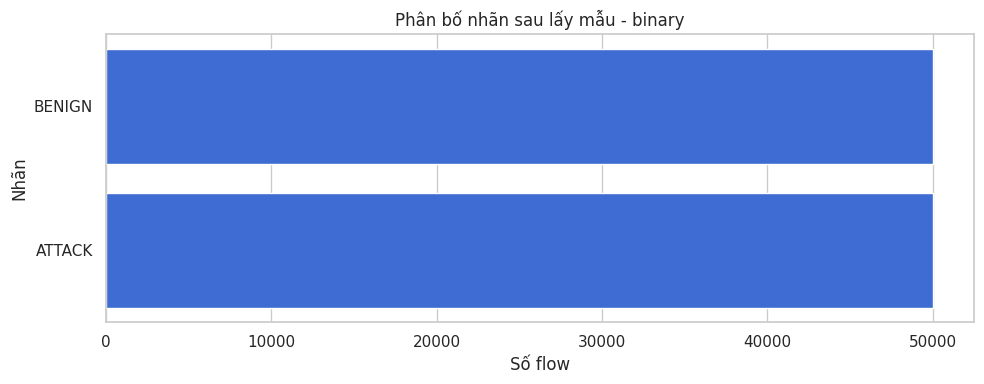

In [ ]:
label_counts_before = raw_df["Label"].value_counts()

if TASK == "multiclass":
    rare_classes = label_counts_before[label_counts_before < MIN_SAMPLES_PER_CLASS].index.tolist()
    if rare_classes:
        print("Loại các lớp quá ít mẫu:", rare_classes)
        raw_df = raw_df[~raw_df["Label"].isin(rare_classes)].copy()

balanced_parts = []
for label, group in raw_df.groupby("Label", sort=True):
    n = min(len(group), MAX_ROWS_PER_CLASS)
    balanced_parts.append(group.sample(n=n, random_state=SEED))

df = (
    pd.concat(balanced_parts, ignore_index=True)
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)
del raw_df, balanced_parts
gc.collect()

counts = df["Label"].value_counts().sort_values(ascending=False)
display(counts.rename("count").to_frame())

plt.figure(figsize=(10, max(4, 0.35 * len(counts))))
sns.barplot(x=counts.values, y=counts.index, color="#2563eb")
plt.title(f"Phân bố nhãn sau lấy mẫu - {TASK}")
plt.xlabel("Số flow")
plt.ylabel("Nhãn")
plt.tight_layout()
plt.show()


## 4. Chia Train / Validation / Test trước khi fit preprocessing

Những cột định danh (`Flow ID`, IP, timestamp, file nguồn) bị loại để giảm nguy cơ mô hình ghi nhớ danh tính hoặc ngày tấn công. Các cột số còn lại được chuyển kiểu; `inf` được đổi thành `NaN`.


In [ ]:
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(df["Label"].astype(str))
class_names = label_encoder.classes_.tolist()
n_classes = len(class_names)

indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(
    indices,
    test_size=TEST_SIZE + VAL_SIZE,
    stratify=y_all,
    random_state=SEED,
)
relative_test_size = TEST_SIZE / (TEST_SIZE + VAL_SIZE)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=relative_test_size,
    stratify=y_all[temp_idx],
    random_state=SEED,
)

print(f"Train: {len(train_idx):,} | Validation: {len(val_idx):,} | Test: {len(test_idx):,}")
print("Classes:", dict(enumerate(class_names)))

# Lưu bản raw của test để dùng live demo và failure analysis.
X_train_raw = df.iloc[train_idx].drop(columns=["Label"]).copy()
X_val_raw = df.iloc[val_idx].drop(columns=["Label"]).copy()
X_test_raw = df.iloc[test_idx].drop(columns=["Label"]).copy()
y_train = y_all[train_idx]
y_val = y_all[val_idx]
y_test = y_all[test_idx]

del df, y_all, indices, temp_idx
gc.collect()


Train: 70,000 | Validation: 15,000 | Test: 15,000
Classes: {0: 'ATTACK', 1: 'BENIGN'}


147

In [ ]:
def canonical_name(name):
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


identifier_names = {
    "flowid", "srcip", "sourceip", "dstip", "destinationip",
    "timestamp", "datetime", "date", "time", "sourcefile"
}

candidate_columns = [
    c for c in X_train_raw.columns
    if canonical_name(c) not in identifier_names and c != "__source_file"
]


def to_numeric_frame(frame, columns):
    out = pd.DataFrame(index=frame.index)
    for column in columns:
        out[column] = pd.to_numeric(frame[column], errors="coerce")
    return out.replace([np.inf, -np.inf], np.nan)


train_numeric = to_numeric_frame(X_train_raw, candidate_columns)

# Chọn cột dựa trên train: không dùng thông tin validation/test.
feature_columns = [
    c for c in train_numeric.columns
    if not train_numeric[c].isna().all() and train_numeric[c].nunique(dropna=True) > 1
]
train_medians = train_numeric[feature_columns].median()

def clean_numeric(frame):
    numeric = to_numeric_frame(frame, feature_columns)
    return numeric.fillna(train_medians).astype("float32")

X_train_num = clean_numeric(X_train_raw)
X_val_num = clean_numeric(X_val_raw)
X_test_num = clean_numeric(X_test_raw)

scaler = RobustScaler(quantile_range=(10.0, 90.0))
X_train = scaler.fit_transform(X_train_num).astype("float32")
X_val = scaler.transform(X_val_num).astype("float32")
X_test = scaler.transform(X_test_num).astype("float32")

# Chặn ngoại lệ quá lớn để gradient ổn định hơn.
X_train = np.clip(X_train, -10, 10)
X_val = np.clip(X_val, -10, 10)
X_test = np.clip(X_test, -10, 10)

n_features = X_train.shape[1]
print("Số đặc trưng sử dụng:", n_features)
print("NaN sau preprocessing:", np.isnan(X_train).sum())
print("Train shape:", X_train.shape)
display(pd.DataFrame({"feature": feature_columns[:20]}))

del train_numeric, X_train_num, X_val_num, X_test_num
gc.collect()


Số đặc trưng sử dụng: 71
NaN sau preprocessing: 0
Train shape: (70000, 71)


,feature
0,Dst Port
1,Protocol
2,Flow Duration
3,Tot Fwd Pkts
4,Tot Bwd Pkts
5,TotLen Fwd Pkts
6,TotLen Bwd Pkts
7,Fwd Pkt Len Max
8,Fwd Pkt Len Min
9,Fwd Pkt Len Mean


2483

In [ ]:
classes_in_train = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes_in_train, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes_in_train, weights)}
print("Class weights:", {class_names[k]: round(v, 3) for k, v in class_weight.items()})

X_train_seq = X_train[..., np.newaxis]
X_val_seq = X_val[..., np.newaxis]
X_test_seq = X_test[..., np.newaxis]

output_units = n_classes
loss_fn = keras.losses.SparseCategoricalCrossentropy()


Class weights: {'ATTACK': 1.0, 'BENIGN': 1.0}


# Từ phần dưới là quá trình train và so sánh những model đã học, không rõ ý "huấn luyện và đánh giá kiến trúc Transformer và so sánh với 2 thuật toán đã học" ở nhiệm vụ chi tiết là gì, nhưng cũng tiện để "phân tích ưu/nhược điểm kiến trúc đã chọn" giống trong rubric. Your choice ,idk. Lúc live demo cũng chỉ chọn model có Macro-F1 tốt nhất.

## 5. Xây dựng bốn kiến trúc

Tất cả mô hình dùng cùng dữ liệu và cùng callback để phép so sánh công bằng.

- **MLP:** Dense → BatchNorm → ReLU → Dropout.
- **CNN:** Conv1D học mẫu cục bộ trên dãy đặc trưng.
- **BiLSTM:** học phụ thuộc hai chiều trên thứ tự đặc trưng đã cố định.
- **Transformer:** chiếu mỗi scalar thành vector, thêm positional embedding, sau đó self-attention và feed-forward residual block.

Công thức scaled dot-product attention:

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$


In [ ]:
# @title
def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=loss_fn,
        metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
    )
    return model


def build_mlp(n_features, n_classes):
    inputs = keras.Input(shape=(n_features,), name="flow_features")
    x = layers.Dense(128, use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return compile_model(keras.Model(inputs, outputs, name="MLP"))


def build_cnn(n_features, n_classes):
    inputs = keras.Input(shape=(n_features, 1), name="feature_sequence")
    x = layers.Conv1D(64, 5, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return compile_model(keras.Model(inputs, outputs, name="CNN1D"))


def build_bilstm(n_features, n_classes):
    inputs = keras.Input(shape=(n_features, 1), name="feature_sequence")
    x = layers.Bidirectional(
        layers.LSTM(48, return_sequences=True), name="bilstm_sequence"
    )(inputs)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(
        layers.LSTM(24), name="bilstm_summary"
    )(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    return compile_model(keras.Model(inputs, outputs, name="BiLSTM"))


In [ ]:
@keras.utils.register_keras_serializable(package="NetworkAD")
class LearnablePositionEmbedding(layers.Layer):
    # Thêm vector vị trí học được cho từng đặc trưng.

    def build(self, input_shape):
        sequence_length = int(input_shape[1])
        embedding_dim = int(input_shape[2])
        self.position_embeddings = self.add_weight(
            name="position_embeddings",
            shape=(1, sequence_length, embedding_dim),
            initializer="random_normal",
            trainable=True,
        )

    def call(self, inputs):
        return inputs + self.position_embeddings


def build_transformer(n_features, n_classes, d_model=64, num_heads=4, ff_dim=128):
    inputs = keras.Input(shape=(n_features, 1), name="feature_sequence")
    x = layers.Dense(d_model, name="scalar_projection")(inputs)
    x = LearnablePositionEmbedding(name="position_embedding")(x)

    attention_layer = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=0.10,
        name="self_attention",
    )
    attention_output, attention_scores = attention_layer(
        x, x, return_attention_scores=True
    )
    x = layers.LayerNormalization(epsilon=1e-6)(
        x + layers.Dropout(0.10)(attention_output)
    )

    ffn = layers.Dense(ff_dim, activation="gelu")(x)
    ffn = layers.Dropout(0.10)(ffn)
    ffn = layers.Dense(d_model)(ffn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="class_probability")(x)

    model = compile_model(keras.Model(inputs, outputs, name="Transformer"))
    attention_model = keras.Model(inputs, attention_scores, name="AttentionInspector")
    return model, attention_model


transformer_model, transformer_attention_model = build_transformer(n_features, n_classes)
models_to_train = {
    "MLP": (build_mlp(n_features, n_classes), "flat"),
    "CNN1D": (build_cnn(n_features, n_classes), "sequence"),
    "BiLSTM": (build_bilstm(n_features, n_classes), "sequence"),
    "Transformer": (transformer_model, "sequence"),
}

for name, (model, input_kind) in models_to_train.items():
    print(f"{name:12s} | input={input_kind:8s} | params={model.count_params():,}")


MLP          | input=flat     | params=18,178
CNN1D        | input=sequence | params=34,050
BiLSTM       | input=sequence | params=45,698
Transformer  | input=sequence | params=42,434


## 6. Huấn luyện và đánh giá công bằng

`EarlyStopping` dừng khi validation loss không cải thiện; `ModelCheckpoint` giữ epoch tốt nhất. Test set chỉ được dùng sau khi huấn luyện xong.


In [ ]:
histories = {}
trained_models = {}
model_input_kind = {}
prediction_probabilities = {}
result_rows = []


def inputs_for(kind, split):
    if kind == "flat":
        return {"train": X_train, "val": X_val, "test": X_test}[split]
    return {"train": X_train_seq, "val": X_val_seq, "test": X_test_seq}[split]


for name, (model, input_kind) in models_to_train.items():
    print("\n" + "=" * 72)
    print("Training", name)
    checkpoint_path = ARTIFACT_DIR / f"{name}.keras"
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor="val_loss", save_best_only=True, verbose=0
        ),
    ]

    start = time.perf_counter()
    history = model.fit(
        inputs_for(input_kind, "train"),
        y_train,
        validation_data=(inputs_for(input_kind, "val"), y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1,
    )
    elapsed = time.perf_counter() - start

    best_model = keras.models.load_model(checkpoint_path)
    probabilities = best_model.predict(
        inputs_for(input_kind, "test"), batch_size=BATCH_SIZE, verbose=0
    )
    predictions = probabilities.argmax(axis=1)
    test_loss, test_accuracy = best_model.evaluate(
        inputs_for(input_kind, "test"), y_test, batch_size=BATCH_SIZE, verbose=0
    )

    row = {
        "Model": name,
        "Parameters": best_model.count_params(),
        "Train_seconds": elapsed,
        "Best_epoch": int(np.argmin(history.history["val_loss"]) + 1),
        "Test_loss": float(test_loss),
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "Macro_F1": f1_score(y_test, predictions, average="macro"),
        "Weighted_F1": f1_score(y_test, predictions, average="weighted"),
    }
    if n_classes == 2:
        attack_index = class_names.index("ATTACK") if "ATTACK" in class_names else 1
        y_attack = (y_test == attack_index).astype(int)
        row["ROC_AUC"] = roc_auc_score(y_attack, probabilities[:, attack_index])
        row["PR_AUC"] = average_precision_score(y_attack, probabilities[:, attack_index])

    histories[name] = history.history
    trained_models[name] = best_model
    model_input_kind[name] = input_kind
    prediction_probabilities[name] = probabilities
    result_rows.append(row)
    print(pd.Series(row))

results_df = pd.DataFrame(result_rows).sort_values("Macro_F1", ascending=False).reset_index(drop=True)
display(results_df.style.format(precision=4))



Training MLP
Epoch 1/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.8810 - loss: 0.3066 - val_accuracy: 0.9347 - val_loss: 0.1959 - learning_rate: 0.0010
Epoch 2/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9334 - loss: 0.1893 - val_accuracy: 0.9429 - val_loss: 0.1637 - learning_rate: 0.0010
Epoch 3/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9446 - loss: 0.1658 - val_accuracy: 0.9457 - val_loss: 0.1442 - learning_rate: 0.0010
Epoch 4/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9544 - loss: 0.1470 - val_accuracy: 0.9595 - val_loss: 0.1280 - learning_rate: 0.0010
Epoch 5/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9613 - loss: 0.1325 - val_accuracy: 0.9677 - val_loss: 0.1150 - learning_rate: 0.0010
Epoch 6/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9647 - loss: 0.1233 - val_accuracy: 0.9689 - val_loss: 0.1086 - learning_rate: 0.0010
Epoch 7/15
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9666 - 

,Model,Parameters,Train_seconds,Best_epoch,Test_loss,Accuracy,Balanced_accuracy,Macro_F1,Weighted_F1,ROC_AUC,PR_AUC
0,MLP,18178,17.1503,14,0.1015,0.9679,0.9679,0.9679,0.9679,0.9859,0.9900
1,BiLSTM,45698,65.2565,15,0.1102,0.9669,0.9669,0.9668,0.9668,0.9828,0.9882
2,Transformer,42434,54.9071,15,0.1187,0.9649,0.9649,0.9649,0.9649,0.9825,0.9879
3,CNN1D,34050,23.8475,13,0.1316,0.9612,0.9612,0.9612,0.9612,0.9808,0.9866


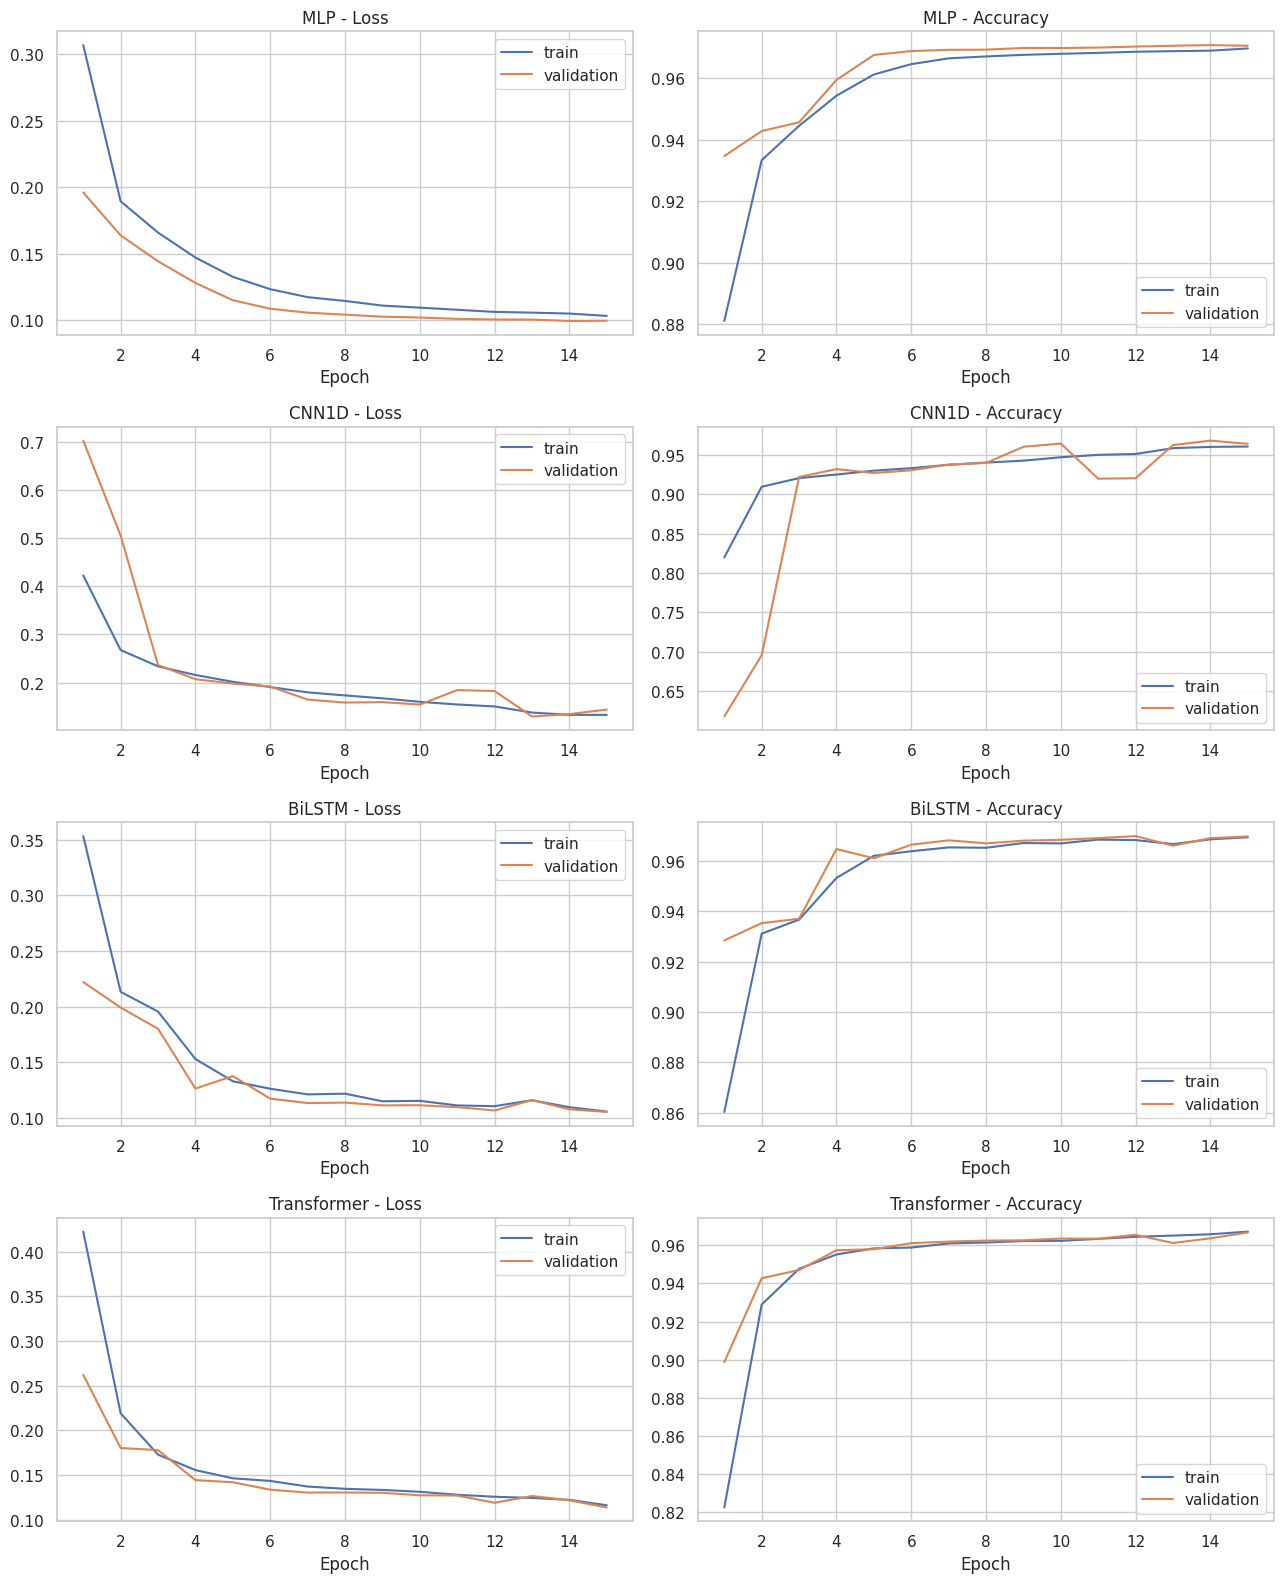

In [ ]:
# Loss/accuracy train-validation của mọi mô hình.
fig, axes = plt.subplots(len(histories), 2, figsize=(13, 4 * len(histories)))
if len(histories) == 1:
    axes = np.array([axes])

for row_idx, (name, history) in enumerate(histories.items()):
    epochs_ran = np.arange(1, len(history["loss"]) + 1)
    axes[row_idx, 0].plot(epochs_ran, history["loss"], label="train")
    axes[row_idx, 0].plot(epochs_ran, history["val_loss"], label="validation")
    axes[row_idx, 0].set_title(f"{name} - Loss")
    axes[row_idx, 0].set_xlabel("Epoch")
    axes[row_idx, 0].legend()

    axes[row_idx, 1].plot(epochs_ran, history["accuracy"], label="train")
    axes[row_idx, 1].plot(epochs_ran, history["val_accuracy"], label="validation")
    axes[row_idx, 1].set_title(f"{name} - Accuracy")
    axes[row_idx, 1].set_xlabel("Epoch")
    axes[row_idx, 1].legend()

plt.tight_layout()
plt.show()


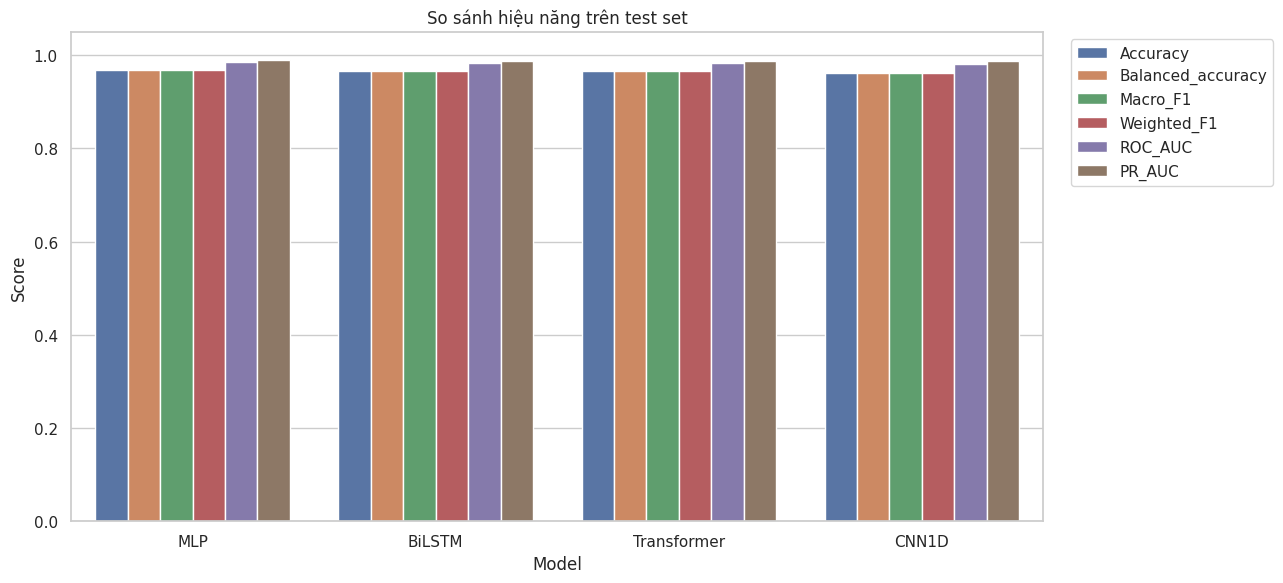

In [ ]:
metric_columns = ["Accuracy", "Balanced_accuracy", "Macro_F1", "Weighted_F1"]
if n_classes == 2:
    metric_columns += ["ROC_AUC", "PR_AUC"]

comparison_long = results_df.melt(
    id_vars="Model", value_vars=metric_columns, var_name="Metric", value_name="Score"
)
plt.figure(figsize=(13, 6))
sns.barplot(data=comparison_long, x="Model", y="Score", hue="Metric")
plt.ylim(0, 1.05)
plt.title("So sánh hiệu năng trên test set")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


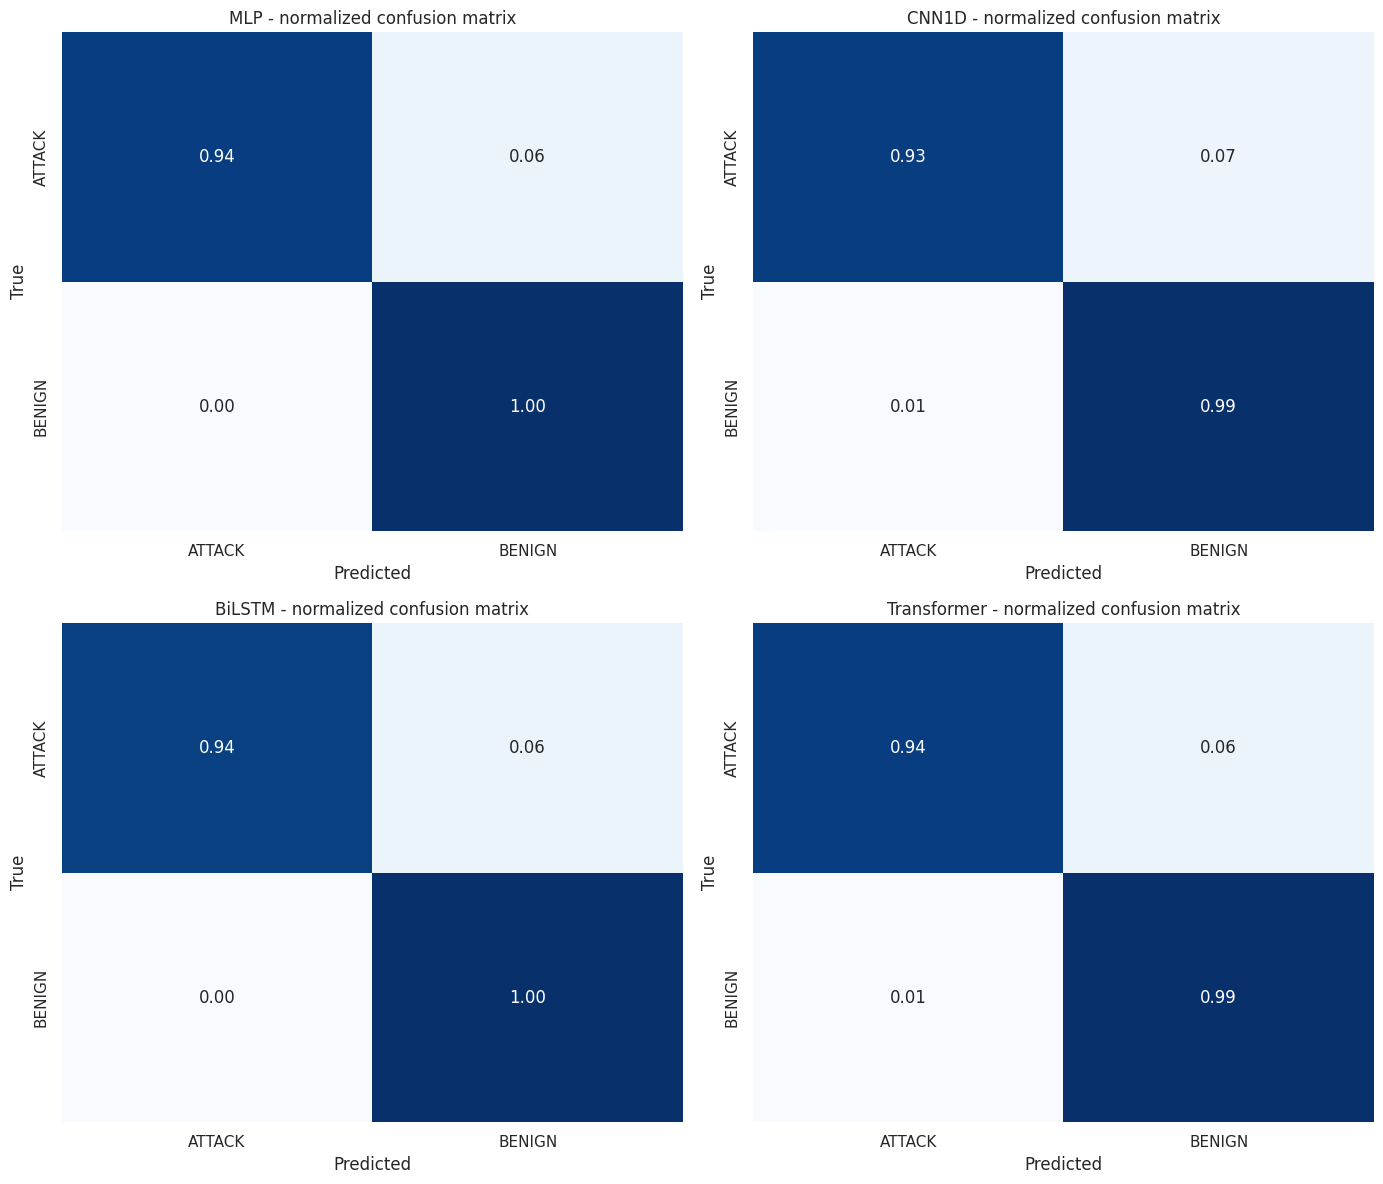

In [ ]:
# Confusion matrix cho từng mô hình, bao gồm CNN theo yêu cầu rubric.
n_models = len(prediction_probabilities)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
axes = np.array(axes).reshape(-1)

for axis, (name, probabilities) in zip(axes, prediction_probabilities.items()):
    predictions = probabilities.argmax(axis=1)
    matrix = confusion_matrix(y_test, predictions, labels=np.arange(n_classes))
    matrix = matrix / np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    sns.heatmap(
        matrix,
        annot=(n_classes <= 6),
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axis,
        cbar=False,
    )
    axis.set_title(f"{name} - normalized confusion matrix")
    axis.set_xlabel("Predicted")
    axis.set_ylabel("True")

for axis in axes[n_models:]:
    axis.axis("off")
plt.tight_layout()
plt.show()


## 7. Phân tích chi tiết mô hình tốt nhất

Mô hình tốt nhất được chọn theo **Macro-F1 trên test** để phục vụ báo cáo so sánh. Trong nghiên cứu nghiêm ngặt hơn, nên chọn cấu hình bằng validation rồi chỉ mở test đúng một lần; ở đây tất cả cấu hình đã được cố định trước, test dùng để tổng kết cuối cùng.


Best model: MLP
              precision    recall  f1-score   support

      ATTACK     0.9966    0.9391    0.9670      7500
      BENIGN     0.9424    0.9968    0.9688      7500

    accuracy                         0.9679     15000
   macro avg     0.9695    0.9679    0.9679     15000
weighted avg     0.9695    0.9679    0.9679     15000



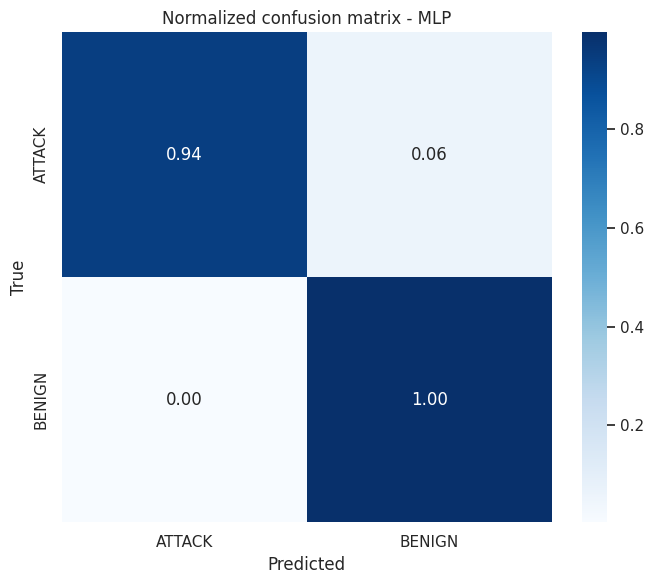

In [ ]:
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
best_input_kind = model_input_kind[best_name]
best_probabilities = prediction_probabilities[best_name]
best_predictions = best_probabilities.argmax(axis=1)

print("Best model:", best_name)
print(classification_report(
    y_test,
    best_predictions,
    labels=np.arange(n_classes),
    target_names=class_names,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(y_test, best_predictions, labels=np.arange(n_classes))
cm_normalized = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig_width = max(7, 0.75 * n_classes)
fig_height = max(6, 0.65 * n_classes)
plt.figure(figsize=(fig_width, fig_height))
sns.heatmap(
    cm_normalized,
    annot=(n_classes <= 10),
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title(f"Normalized confusion matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


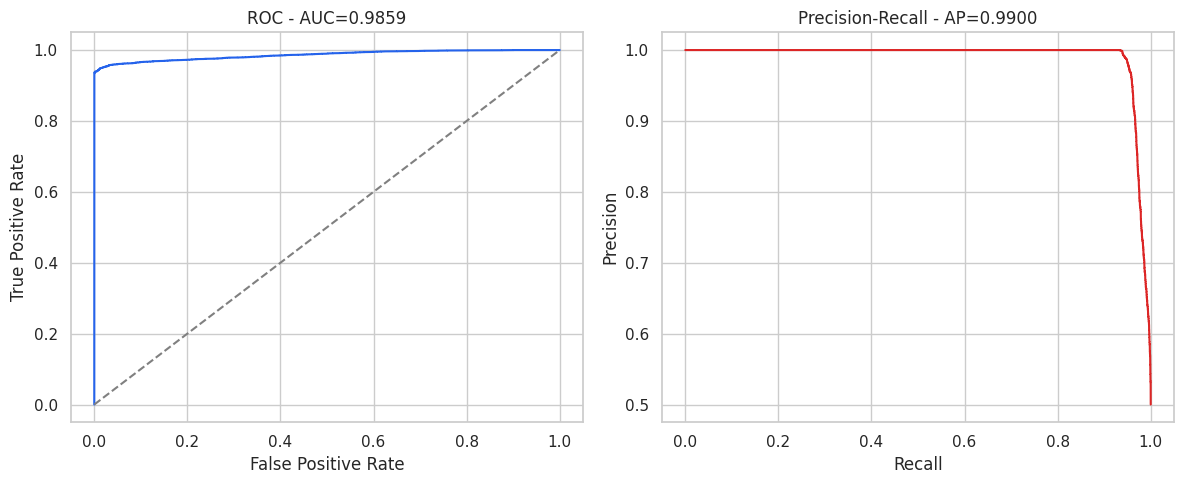

In [ ]:
if n_classes == 2:
    attack_index = class_names.index("ATTACK") if "ATTACK" in class_names else 1
    y_attack = (y_test == attack_index).astype(int)
    attack_score = best_probabilities[:, attack_index]
    fpr, tpr, _ = roc_curve(y_attack, attack_score)
    precision, recall, _ = precision_recall_curve(y_attack, attack_score)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(fpr, tpr, color="#2563eb")
    axes[0].plot([0, 1], [0, 1], "--", color="gray")
    axes[0].set_title(f"ROC - AUC={roc_auc_score(y_attack, attack_score):.4f}")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")

    axes[1].plot(recall, precision, color="#dc2626")
    axes[1].set_title(f"Precision-Recall - AP={average_precision_score(y_attack, attack_score):.4f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    plt.tight_layout()
    plt.show()


## 8. Prediction visualization và failure analysis

Bảng dưới ưu tiên các lỗi có confidence cao. Đây là các trường hợp quan trọng nhất để trình bày: mô hình không chỉ sai mà còn **tự tin rằng mình đúng**.


In [ ]:
rng = np.random.default_rng(SEED)
demo_indices = rng.choice(len(y_test), size=min(20, len(y_test)), replace=False)
prediction_view = pd.DataFrame({
    "Actual": label_encoder.inverse_transform(y_test[demo_indices]),
    "Predicted": label_encoder.inverse_transform(best_predictions[demo_indices]),
    "Confidence": best_probabilities[demo_indices].max(axis=1),
    "Correct": y_test[demo_indices] == best_predictions[demo_indices],
})
display(prediction_view.style.format({"Confidence": "{:.3f}"}))


,Actual,Predicted,Confidence,Correct
0,BENIGN,BENIGN,0.962,True
1,ATTACK,ATTACK,1.000,True
2,BENIGN,BENIGN,0.987,True
3,BENIGN,BENIGN,0.994,True
4,BENIGN,BENIGN,0.987,True
5,ATTACK,ATTACK,0.999,True
6,ATTACK,ATTACK,1.000,True
7,BENIGN,BENIGN,0.999,True
8,ATTACK,ATTACK,0.994,True
9,BENIGN,BENIGN,0.938,True


In [ ]:
error_mask = best_predictions != y_test
error_positions = np.flatnonzero(error_mask)

if len(error_positions) == 0:
    print("Không có lỗi trên test sample hiện tại. Hãy thử multiclass hoặc split theo ngày để đánh giá khó hơn.")
else:
    failures = pd.DataFrame({
        "Test_position": error_positions,
        "Actual": label_encoder.inverse_transform(y_test[error_positions]),
        "Predicted": label_encoder.inverse_transform(best_predictions[error_positions]),
        "Confidence": best_probabilities[error_positions].max(axis=1),
        "Source_file": X_test_raw.iloc[error_positions]["__source_file"].values
            if "__source_file" in X_test_raw.columns else "unknown",
    }).sort_values("Confidence", ascending=False)
    print(f"Số dự đoán sai: {len(failures):,}/{len(y_test):,} ({len(failures)/len(y_test):.2%})")
    display(failures.head(20).style.format({"Confidence": "{:.4f}"}))

    failure_pairs = (
        failures.groupby(["Actual", "Predicted"]).size()
        .sort_values(ascending=False)
        .head(15)
        .rename("Errors")
        .reset_index()
    )
    display(failure_pairs)


Số dự đoán sai: 481/15,000 (3.21%)


,Test_position,Actual,Predicted,Confidence,Source_file
120,4024,ATTACK,BENIGN,0.9974,03-01-2018.csv
320,10075,ATTACK,BENIGN,0.9966,03-01-2018.csv
207,6779,ATTACK,BENIGN,0.9965,02-23-2018.csv
143,4653,ATTACK,BENIGN,0.9962,03-01-2018.csv
165,5399,ATTACK,BENIGN,0.9943,02-23-2018.csv
350,11071,ATTACK,BENIGN,0.9943,03-01-2018.csv
91,3291,ATTACK,BENIGN,0.9905,03-01-2018.csv
366,11579,ATTACK,BENIGN,0.9901,03-01-2018.csv
392,12592,ATTACK,BENIGN,0.9896,03-01-2018.csv
347,10960,ATTACK,BENIGN,0.9855,03-01-2018.csv


,Actual,Predicted,Errors
0,ATTACK,BENIGN,457
1,BENIGN,ATTACK,24


## 9. Trực quan hóa Attention của Transformer

Mỗi attention score đo mức một vị trí truy vấn chú ý tới một vị trí khóa. Biểu đồ lấy trung bình theo mẫu, head và vị trí truy vấn để ước lượng các đặc trưng được nhận nhiều attention nhất.

> Attention giúp giải thích hành vi mô hình nhưng **không phải** bằng chứng nhân quả tuyệt đối.


,Feature,Mean_attention_received
0,Src Port,0.022113
1,Down/Up Ratio,0.020020
2,Init Bwd Win Byts,0.019481
3,Dst Port,0.016540
4,Fwd Seg Size Min,0.016000
5,Bwd IAT Min,0.015298
6,Bwd Pkts/s,0.015139
7,Fwd IAT Min,0.014951
8,Init Fwd Win Byts,0.014834
9,Active Min,0.014791


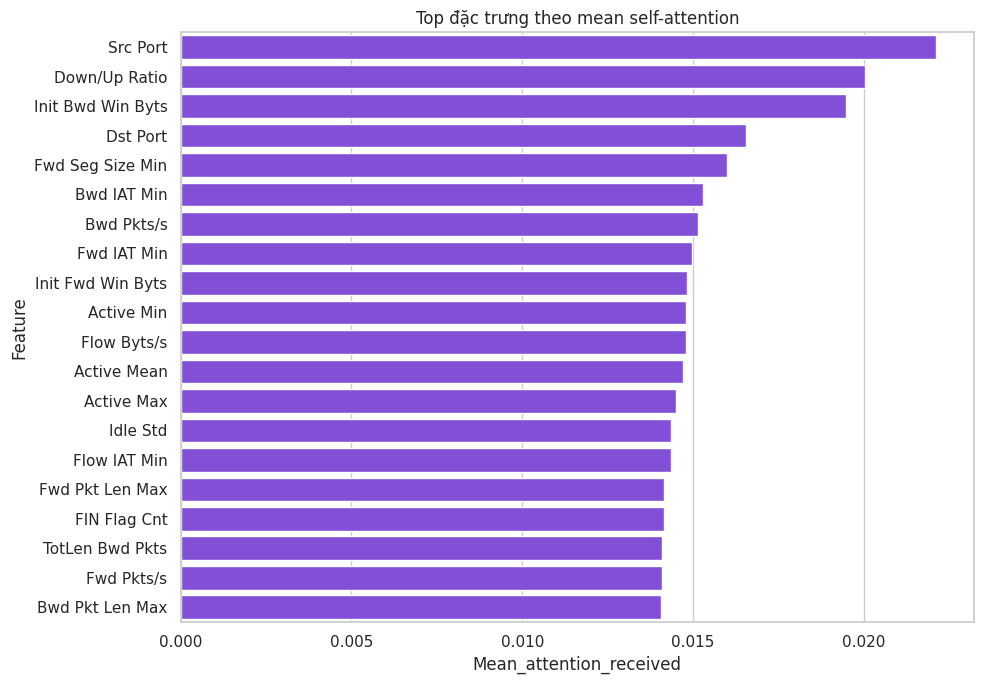

In [ ]:
# AttentionInspector dùng cùng weights với transformer_model đã huấn luyện trong vòng lặp.
# Đồng bộ weights tốt nhất từ checkpoint vào model/inspector gốc.
transformer_best = trained_models["Transformer"]
transformer_model.set_weights(transformer_best.get_weights())

attention_sample_size = min(256, len(X_test_seq))
attention_scores = transformer_attention_model.predict(
    X_test_seq[:attention_sample_size], batch_size=64, verbose=0
)
# shape: [batch, heads, query_feature, key_feature]
feature_attention = attention_scores.mean(axis=(0, 1, 2))
top_k = min(20, len(feature_columns))
top_indices = np.argsort(feature_attention)[-top_k:][::-1]

attention_df = pd.DataFrame({
    "Feature": np.array(feature_columns)[top_indices],
    "Mean_attention_received": feature_attention[top_indices],
})
display(attention_df)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=attention_df,
    x="Mean_attention_received",
    y="Feature",
    color="#7c3aed",
)
plt.title("Top đặc trưng theo mean self-attention")
plt.tight_layout()
plt.show()


## 9.1. Trực quan hóa biểu diễn ẩn của BiLSTM

Lấy vector hidden representation từ tầng `bilstm_summary`, giảm xuống hai chiều bằng PCA và tô màu theo nhãn thật. Các cụm tách biệt cho thấy LSTM đã học được biểu diễn hữu ích; vùng chồng lấn thường liên quan đến các ca dễ nhầm.


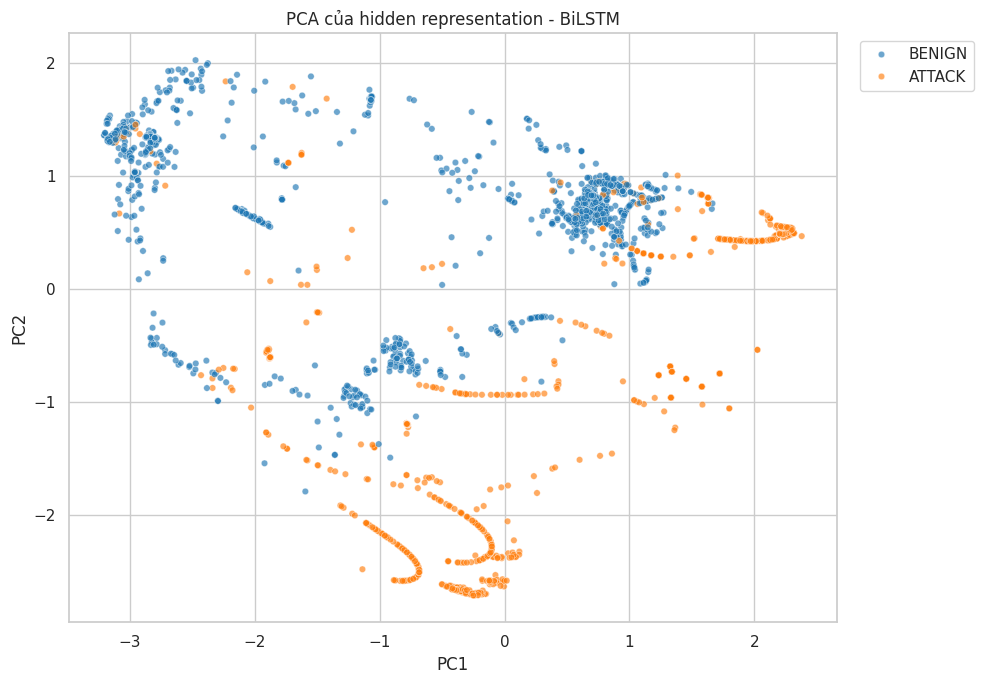

In [ ]:
bilstm_best = trained_models["BiLSTM"]
hidden_model = keras.Model(
    inputs=bilstm_best.input,
    outputs=bilstm_best.get_layer("bilstm_summary").output,
)
hidden_sample_size = min(3_000, len(X_test_seq))
hidden_states = hidden_model.predict(
    X_test_seq[:hidden_sample_size], batch_size=BATCH_SIZE, verbose=0
)
hidden_2d = PCA(n_components=2, random_state=SEED).fit_transform(hidden_states)
hidden_df = pd.DataFrame({
    "PC1": hidden_2d[:, 0],
    "PC2": hidden_2d[:, 1],
    "Label": label_encoder.inverse_transform(y_test[:hidden_sample_size]),
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=hidden_df,
    x="PC1",
    y="PC2",
    hue="Label",
    s=22,
    alpha=0.65,
    palette="tab10",
)
plt.title("PCA của hidden representation - BiLSTM")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 10. Live demo: dự đoán một flow chưa dùng để train

Cell này chọn ngẫu nhiên một flow trong **test set**, thực hiện preprocessing bằng scaler đã fit trên train và trả về nhãn cùng xác suất. Khi bảo vệ, chạy lại cell để sinh input ngẫu nhiên khác.


In [ ]:
def preprocess_raw_flows(raw_flows):
    raw_flows = raw_flows.copy()
    raw_flows.columns = [str(c).strip() for c in raw_flows.columns]
    missing = [c for c in feature_columns if c not in raw_flows.columns]
    if missing:
        raise ValueError(f"Input thiếu {len(missing)} đặc trưng. Ví dụ: {missing[:8]}")

    numeric = to_numeric_frame(raw_flows, feature_columns)
    numeric = numeric.fillna(train_medians).astype("float32")
    transformed = scaler.transform(numeric).astype("float32")
    return np.clip(transformed, -10, 10)


def predict_raw_flows(raw_flows, model=best_model, input_kind=best_input_kind):
    transformed = preprocess_raw_flows(raw_flows)
    model_input = transformed if input_kind == "flat" else transformed[..., np.newaxis]
    probabilities = model.predict(model_input, verbose=0)
    predicted_ids = probabilities.argmax(axis=1)
    output = pd.DataFrame({
        "Prediction": label_encoder.inverse_transform(predicted_ids),
        "Confidence": probabilities.max(axis=1),
    })
    for class_id, class_name in enumerate(class_names):
        output[f"P({class_name})"] = probabilities[:, class_id]
    return output


random_position = int(np.random.default_rng().integers(0, len(X_test_raw)))
live_input = X_test_raw.iloc[[random_position]]
live_output = predict_raw_flows(live_input)

print("Mô hình:", best_name)
print("Nhãn thật:", label_encoder.inverse_transform([y_test[random_position]])[0])
display(live_output.style.format({c: "{:.4f}" for c in live_output.columns if c != "Prediction"}))


Mô hình: MLP
Nhãn thật: BENIGN


,Prediction,Confidence,P(ATTACK),P(BENIGN)
0,BENIGN,0.9616,0.0384,0.9616


## 11. Lưu mô hình, preprocessing và kết quả

File ZIP chứa:

- `best_network_anomaly_model.keras`
- `preprocessing.joblib`
- `model_comparison.csv`
- `experiment_config.json`


In [ ]:
best_model_path = ARTIFACT_DIR / "best_network_anomaly_model.keras"
best_model.save(best_model_path)

preprocessing_bundle = {
    "feature_columns": feature_columns,
    "train_medians": train_medians,
    "scaler": scaler,
    "label_encoder": label_encoder,
    "task": TASK,
    "best_model_name": best_name,
    "input_kind": best_input_kind,
    "clip_range": (-10, 10),
}
joblib.dump(preprocessing_bundle, ARTIFACT_DIR / "preprocessing.joblib")
results_df.to_csv(ARTIFACT_DIR / "model_comparison.csv", index=False)

experiment_config = {
    "seed": SEED,
    "task": TASK,
    "train_rows": int(len(y_train)),
    "validation_rows": int(len(y_val)),
    "test_rows": int(len(y_test)),
    "n_features": int(n_features),
    "class_names": class_names,
    "epochs_max": EPOCHS,
    "batch_size": BATCH_SIZE,
    "best_model": best_name,
}
with open(ARTIFACT_DIR / "experiment_config.json", "w", encoding="utf-8") as file:
    json.dump(experiment_config, file, ensure_ascii=False, indent=2)

archive_path = shutil.make_archive(
    "/content/cicids2018_final_artifacts", "zip", root_dir=ARTIFACT_DIR
)
print("Đã tạo:", archive_path)

# Bỏ comment hai dòng dưới nếu muốn tải ZIP về máy.
# from google.colab import files
# files.download(archive_path)


Đã tạo: /content/cicids2018_final_artifacts.zip


## Checklist

- [ ] Chạy `Runtime > Run all` thành công từ đầu đến cuối.
- [ ] Ghi lại phiên bản dữ liệu, số file, số dòng và phân bố lớp.
- [ ] Chụp bảng `results_df`, loss curves, confusion matrix và failure analysis cho slide.
- [ ] Không thay đổi test set hoặc chọn mô hình dựa trên vài mẫu demo.
- [ ] Tải ZIP artifacts và thử load lại mô hình trước khi thi.
- [ ] Chuẩn bị bản dữ liệu nhỏ trên Drive để live demo không phụ thuộc tải mạng.
- [ ] README có thành viên, cài đặt, cấu trúc repo, cách chạy và bảng kết quả thật.
- [ ] Slide tối đa 10 trang: Problem, Dataset, Pipeline, Models, Results, Failure Analysis, Improvements, Demo/Conclusion.
